# Zeitreihenanalyse

In diesem Notebook werden verschiedene Zeitreihendatensätze analysiert und miteinander verglichen. Ziel der Analyse ist es, zeitliche Muster, Trends, saisonale Effekte sowie statistische Eigenschaften der Daten zu untersuchen.

Dazu werden drei unterschiedliche Datensätze betrachtet:
- Gold Price Dataset (Goldpreise)
- Apple Stock Dataset (Aktienkurse)
- Weather Dataset (Temperaturdaten)

Die Analyse umfasst die Datenbereinigung, explorative Visualisierung, deskriptive Statistik sowie die Untersuchung zeitlicher Abhängigkeiten mithilfe von Zeitreihenmethoden wie ACF, Stationaritätsanalyse sowie AR-, MA-, ARMA- und ARIMA-Modellen.

## 1. Bibliotheken importieren

Für die Analyse werden Bibliotheken zur Datenverarbeitung, Visualisierung und Modellierung verwendet.

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss

import itertools
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")

## 2. Datensätze laden

Die Datensätze für Amazon Sales, Apple Stock und Wetterdaten werden eingelesen und anschließend überprüft.

In [47]:
gold = pd.read_csv("data/raw/GoldPrice.csv", low_memory=False)
apple   = pd.read_csv("data/raw/apple_stock.csv", header=0, skiprows=[1, 2])
weather = pd.read_csv("data/raw/weather_ts.csv")


## 3. Überblick über die Datensätze

Zur ersten Orientierung werden die Dimensionen und die ersten Zeilen der Datensätze angezeigt.

In [48]:
datasets = {
    "Gold Price": gold,
    "Apple Stock": apple,
    "Weather": weather
}

for name, df in datasets.items():
    print(name)
    print(df.shape)
    display(df.head())
    print("=" * 150)

Gold Price
(2531, 6)


,Date,Price,Open,High,Low,Chg%
0,"Sep 11, 2020",1957.35,1952.55,1963.3,1944.35,-0.0035
1,"Sep 10, 2020",1964.30,1955.30,1975.2,1948.60,0.0048
2,"Sep 09, 2020",1954.90,1939.40,1959.7,1926.30,0.0060
3,"Sep 08, 2020",1943.20,1938.00,1948.3,1911.70,0.0031
4,"Sep 07, 2020",1937.10,1940.70,1947.4,1930.45,-0.0018


Apple Stock
(2596, 6)


,Price,Close,High,Low,Open,Volume
0,2016-01-04,23.730947,23.735454,22.976333,23.113741,270597600
1,2016-01-05,23.136259,23.843569,23.068683,23.821044,223164000
2,2016-01-06,22.683493,23.059675,22.496530,22.651957,273829600
3,2016-01-07,21.726154,22.555105,21.721650,22.228481,324377600
4,2016-01-08,21.841028,22.325334,21.795977,22.199190,283192000


Weather
(420551, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


# 4. Zeitreihenanalyse

### Stil setzen

In [49]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

## Goldpreis im Zeitverlauf

Der wöchentliche Goldpreis zeigt über den gesamten Zeitraum einen langfristigen Aufwärtstrend. Besonders ab 2019 steigt der Goldpreis deutlich an. Kurzfristige Schwankungen sind weiterhin sichtbar, insgesamt entwickelt sich die Zeitreihe jedoch relativ stabil. Die Wochenaggregation reduziert tägliches Rauschen und macht den langfristigen Trend besser erkennbar.

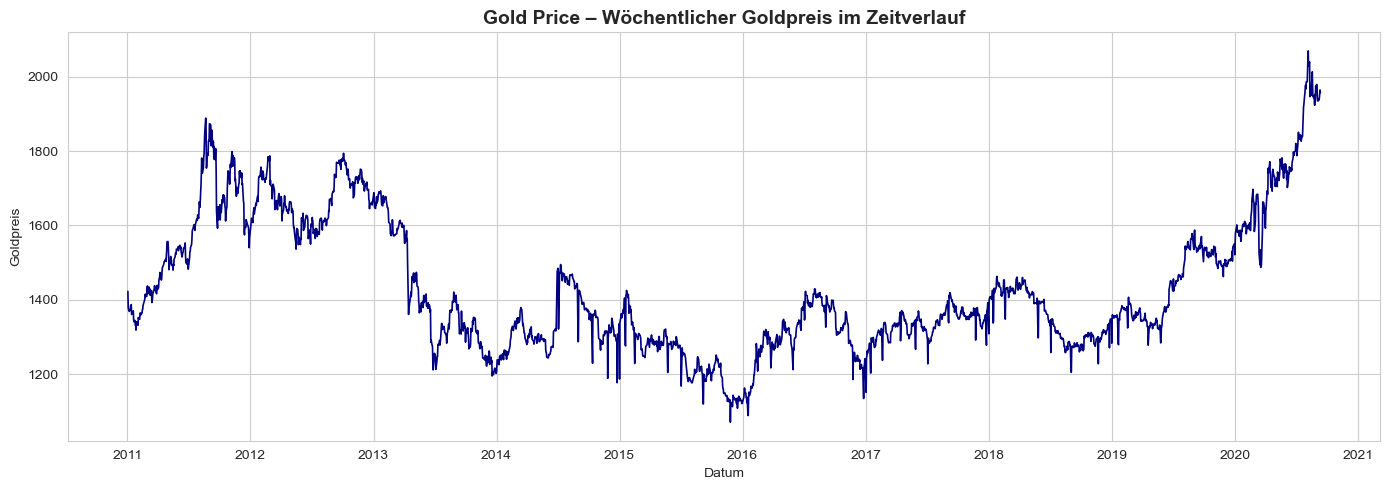

In [50]:
# Gold Price Datensatz vorbereiten
df_gold = datasets["Gold Price"].copy()

# Datum konvertieren
df_gold["Date"] = pd.to_datetime(df_gold["Date"])

# Nach Datum sortieren
df_gold = df_gold.sort_values("Date")

# Preis als numerischen Wert umwandeln
df_gold["Price"] = pd.to_numeric(df_gold["Price"], errors="coerce")
gold_weekly = (df_gold.set_index("Date")["Price"])

# Plot
fig, ax = plt.subplots()

ax.plot(
    gold_weekly.index,
    gold_weekly.values,
    color="navy",
    linewidth=1.2
)

ax.set_title(
    "Gold Price – Wöchentlicher Goldpreis im Zeitverlauf",
    fontsize=14,
    weight="bold"
)
ax.set_ylabel("Goldpreis")
ax.set_xlabel("Datum")
plt.tight_layout()
plt.show()

## Erkenntnisse – Goldpreis im Zeitverlauf

Monatlich aggregierter Gesamtumsatz als Heatmap. Zeigt auf einen Blick ob saisonale Muster (z.B. Q4) oder jahresspezifische Ausreißer existieren.

# Apple Stock

## Kursentwicklung (Close Price)

AAPL hat sich von ~$30 (2016) auf ~$260 (2026) mehr als verachtfacht. Markante Einbrüche: COVID-Crash (März 2020) und Zinsanstieg-Korrektur (2022). Ab 2023 starke Erholung mit neuem Allzeithoch ~$275 Ende 2024.

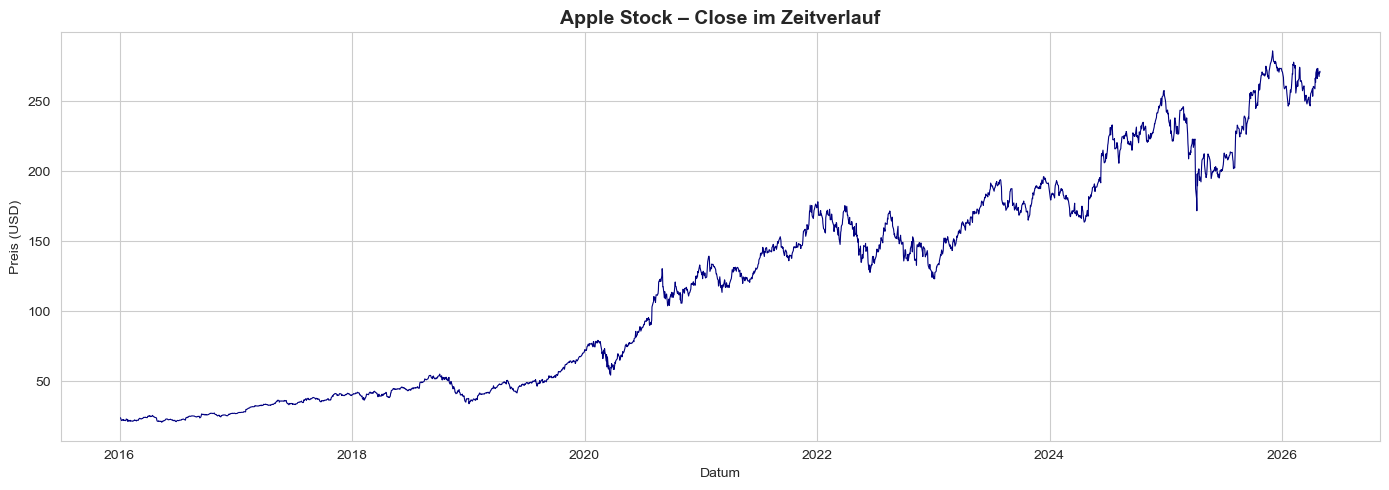

In [51]:
df_apple = datasets["Apple Stock"].copy()
df_apple["Price"] = pd.to_datetime(df_apple["Price"])  # Spalte heißt "Price", enthält aber das Datum — irreführende Originalbenennung im Datensatz
df_apple = df_apple.rename(columns={"Price": "Date"}).set_index("Date")

fig, ax = plt.subplots()
ax.plot(df_apple.index, df_apple["Close"], color="navy", linewidth=0.8)
ax.set_title("Apple Stock – Close im Zeitverlauf", fontsize=14, weight="bold")
ax.set_ylabel("Preis (USD)")
ax.set_xlabel("Datum")

plt.tight_layout()
plt.show()

# Weather 

## Temperaturverlauf (2009–2017)

Klare Saisonalität mit Sommermaxima ~20–35°C und Winterminima bis –20°C. Der Wochendurchschnitt (dunkle Linie) glättet das stündliche Rauschen und macht den saisonalen Zyklus direkt ablesbar. Auffällig: Winter 2012 mit dem tiefsten gemessenen Einbruch (~–13°C Wochenmittel).

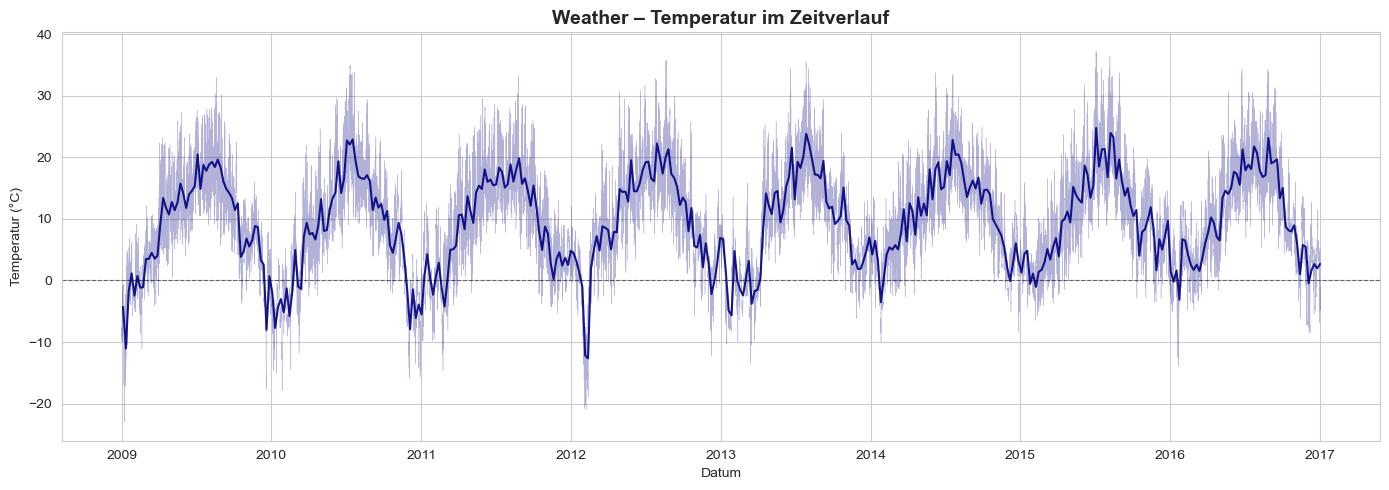

In [52]:
weather_index = pd.to_datetime(datasets["Weather"]["Date Time"], format="%d.%m.%Y %H:%M:%S")

df_temp_weekly = (
    datasets["Weather"]
    .set_index(weather_index)["T (degC)"]
    .resample("W")
    .mean()
)

fig, ax = plt.subplots()
ax.plot(weather_index, datasets["Weather"]["T (degC)"],
        color="navy", linewidth=0.3, alpha=0.3)
ax.plot(df_temp_weekly.index, df_temp_weekly.values,
        color="navy", linewidth=1.5, alpha=0.9)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_title("Weather – Temperatur im Zeitverlauf", fontsize=14, weight="bold")
ax.set_ylabel("Temperatur (°C)")
ax.set_xlabel("Datum")
plt.tight_layout()
plt.show()

## Deskriptive Analyse

## Setup & Datenimport

Die aufbereiteten Wetterdaten werden über das `preprocess`-Modul geladen.
Die Rohdaten lagen im 10-Minuten-Takt vor (>420.000 Zeilen) und wurden
auf tägliche Mittelwerte aggregiert (`T_mean_degC`).

In [53]:
import preprocess

df_weather = preprocess.process_weather()
df_weather.index = pd.to_datetime(df_weather.index)
df_weather = df_weather.asfreq("D")

[Weather] Gespeichert → data/processed/weather_processed.csv


### Fehlende Werte

Durch die Aggregation von 10-Minuten- auf Tagesdaten können einzelne Tage
ohne Messungen entstehen. Diese werden lokalisiert und per linearer
Zeitinterpolation geschlossen — bei Temperaturdaten ist das die sinnvollste
Methode, da kurzfristige Temperaturverläufe näherungsweise linear sind.

In [54]:
print(df_weather[df_weather["T_mean_degC"].isnull()])

            T_mean_degC
Date                   
2016-10-26          NaN
2016-10-27          NaN


In [55]:
df_weather["T_mean_degC"] = df_weather["T_mean_degC"].interpolate(method="time")

In [56]:
print(f"Fehlende Werte: {df_weather.isnull().sum().values[0]}")
print(f"Zeitraum: {df_weather.index.min().date()} bis {df_weather.index.max().date()}")
print(f"Beobachtungen: {len(df_weather)}")

Fehlende Werte: 0
Zeitraum: 2009-01-01 bis 2017-01-01
Beobachtungen: 2923


## 1. Explorative Datenanalyse (EDA)

Ziel der EDA ist ein erstes Verständnis der Datenstruktur: Lage, Streuung,
Verteilung und auffällige Beobachtungen. Nach Menden (Folie 47-48) werden
Summary Statistics, Boxplots und Histogramme als Standardwerkzeuge eingesetzt.

### 1.1 Summary Statistics

In [57]:
print(df_weather["T_mean_degC"].describe().round(2))

count    2923.00
mean        9.44
std         7.84
min       -16.46
25%         3.81
50%         9.71
75%        15.43
max        29.38
Name: T_mean_degC, dtype: float64


### 1.2 Ausreißeranalyse (IQR-Regel)

Ein Datenpunkt gilt als Ausreißer, wenn er mehr als das 1.5-fache des
Interquartilsabstands (IQR) vom ersten bzw. dritten Quartil entfernt liegt.

In [58]:
Q1 = df_weather["T_mean_degC"].quantile(0.25)
Q3 = df_weather["T_mean_degC"].quantile(0.75)
IQR = Q3 - Q1

outliers_weather = df_weather[
    (df_weather["T_mean_degC"] < Q1 - 1.5 * IQR) |
    (df_weather["T_mean_degC"] > Q3 + 1.5 * IQR)
]
print(f"Ausreißer (IQR-Regel): {len(outliers_weather)}")
print(outliers_weather)

Ausreißer (IQR-Regel): 8
            T_mean_degC
Date                   
2009-01-06       -15.48
2009-01-07       -15.73
2009-12-19       -15.98
2012-02-02       -14.56
2012-02-03       -14.45
2012-02-05       -14.58
2012-02-06       -16.46
2012-02-07       -15.36


### 1.3 Visualisierung

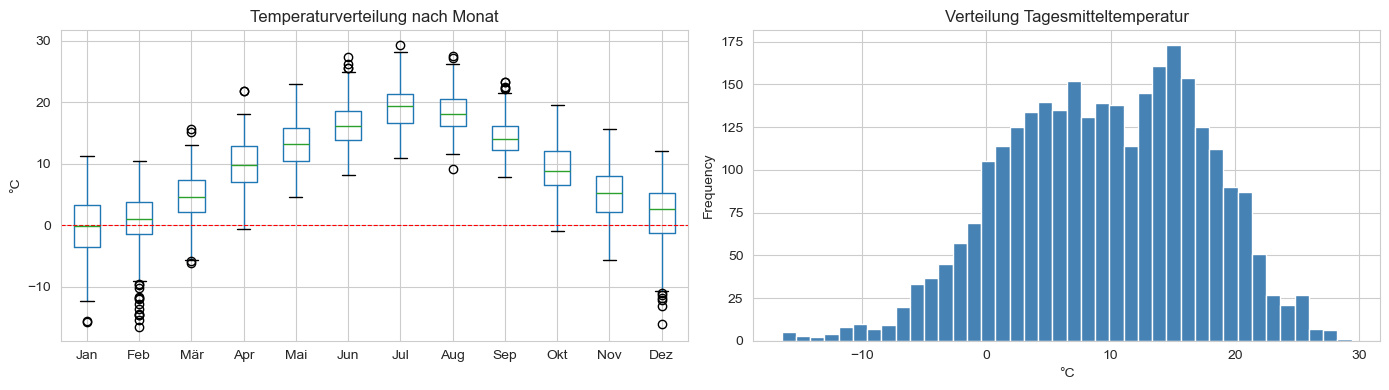

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_weather.groupby(df_weather.index.month)["T_mean_degC"].apply(list).apply(pd.Series).T.boxplot(ax=axes[0])
axes[0].set_xticklabels(["Jan","Feb","Mär","Apr","Mai","Jun","Jul","Aug","Sep","Okt","Nov","Dez"])
axes[0].set_title("Temperaturverteilung nach Monat")
axes[0].set_ylabel("°C")
axes[0].axhline(0, color="red", linestyle="--", linewidth=0.8)

df_weather["T_mean_degC"].plot(kind="hist", bins=40, ax=axes[1], color="steelblue", edgecolor="white")
axes[1].set_title("Verteilung Tagesmitteltemperatur")
axes[1].set_xlabel("°C")

plt.tight_layout()
plt.show()

### 1.4 Interpretation

- **Mittelwert 9.44°C, Std 7.84°C** — plausibel für deutschen Wetterstandort
- **8 Ausreißer** — ausschließlich in Wintermonaten (Jan 2009, Feb 2012),
  extreme Kälteereignisse, keine Messfehler → werden **nicht entfernt**
- **Boxplot** bestätigt klare, stabile Jahressaisonalität ohne erkennbaren
  Langzeittrend
- **Histogramm** zeigt annähernde Normalverteilung mit leichter Linksschiefe
  durch die Kältewinter

## 2. Stationaritätsanalyse

Schwache Stationarität ist eine zentrale Voraussetzung für ARIMA-Modelle
(Menden, Folie 27). Sie erfordert konstanten Mittelwert, konstante Varianz
und zeitinvariante Kovarianzstruktur.

Zur Prüfung werden zwei Tests mit entgegengesetzten Nullhypothesen eingesetzt
— das erhöht die Aussagekraft gegenüber einem einzelnen Test:

| Test | H₀ | H₁ |
|------|----|----|
| ADF  | Nicht stationär (Unit Root) | Stationär |
| KPSS | Stationär | Nicht stationär |

Stimmen beide Tests überein, ist die Aussage eindeutig.

### 2.1 Hilfsfunktion: Stationaritätsreport

In [60]:
def stationarity_report(series, name="Zeitreihe"):
    """Führt ADF und KPSS durch und gibt kompakten Report aus."""
    print(f"{'='*50}")
    print(f"Stationaritätstest: {name}")
    print(f"{'='*50}")

    # ADF Test (H0: nicht stationär / Unit Root)
    adf = adfuller(series.dropna(), autolag="AIC")
    print(f"\nADF Test")
    print(f"  Teststatistik : {adf[0]:.4f}")
    print(f"  p-Wert        : {adf[1]:.4f}")
    print(f"  Lags genutzt  : {adf[2]}")
    print(f"  Krit. Werte   : 1%={adf[4]['1%']:.3f}, 5%={adf[4]['5%']:.3f}, 10%={adf[4]['10%']:.3f}")
    adf_conclusion = "STATIONÄR (H0 abgelehnt)" if adf[1] < 0.05 else "NICHT STATIONÄR (H0 nicht abgelehnt)"
    print(f"  → {adf_conclusion}")

    # KPSS Test (H0: stationär) — umgekehrte H0!
    kpss_result = kpss(series.dropna(), regression="c", nlags="auto")
    print(f"\nKPSS Test")
    print(f"  Teststatistik : {kpss_result[0]:.4f}")
    print(f"  p-Wert        : {kpss_result[1]:.4f}")
    print(f"  Krit. Werte   : {kpss_result[3]}")
    kpss_conclusion = "NICHT STATIONÄR (H0 abgelehnt)" if kpss_result[1] < 0.05 else "STATIONÄR (H0 nicht abgelehnt)"
    print(f"  → {kpss_conclusion}")

### 2.2 Test der Originalreihe

In [61]:
stationarity_report(df_weather["T_mean_degC"], "Original")

Stationaritätstest: Original

ADF Test
  Teststatistik : -3.5869
  p-Wert        : 0.0060
  Lags genutzt  : 18
  Krit. Werte   : 1%=-3.433, 5%=-2.863, 10%=-2.567
  → STATIONÄR (H0 abgelehnt)

KPSS Test
  Teststatistik : 0.2013
  p-Wert        : 0.1000
  Krit. Werte   : {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
  → STATIONÄR (H0 nicht abgelehnt)


### 2.3 Test der saisonal differenzierten Reihe (Lag 365)

Als Vergleich wird zusätzlich die saisonale Differenz (Δ₃₆₅) getestet —
d.h. jeder Wert minus dem Wert vor exakt einem Jahr. Dies eliminiert die
Jahressaisonalität vollständig.

In [62]:
df_weather["T_diff365"] = df_weather["T_mean_degC"].diff(365)
stationarity_report(df_weather["T_diff365"].dropna(), "Saisonale Differenz (Lag 365)")

Stationaritätstest: Saisonale Differenz (Lag 365)

ADF Test
  Teststatistik : -13.6540
  p-Wert        : 0.0000
  Lags genutzt  : 4
  Krit. Werte   : 1%=-3.433, 5%=-2.863, 10%=-2.567
  → STATIONÄR (H0 abgelehnt)

KPSS Test
  Teststatistik : 0.0966
  p-Wert        : 0.1000
  Krit. Werte   : {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
  → STATIONÄR (H0 nicht abgelehnt)


### 2.4 Interpretation & Entscheidung

- **Originalreihe:** ADF (p=0.006) und KPSS (p=0.1) — beide Tests bestätigen
  Stationarität. Die zyklische Jahressaisonalität verletzt die schwache
  Stationarität **nicht**, da Mittelwert und Varianz über die Zeit stabil sind.
- **Saisonale Differenz:** Noch stärker stationär (ADF p≈0.000) — dient als
  Bestätigung.

**Entscheidung:** Wir arbeiten mit der **Originalreihe** (`d=0`) und
modellieren die Jahressaisonalität explizit über Fourier-Terms als exogene
Variablen. Eine unnötige Differenzierung würde Information vernichten.

## 3. ACF & PACF Analyse

ACF (Autokorrelationsfunktion) und PACF (Partielle Autokorrelationsfunktion)
sind das zentrale Werkzeug der Box-Jenkins-Methode zur Identifikation der
Modellordnung (Menden, Folie 66):

| Muster | ACF | PACF |
|--------|-----|------|
| AR(p)  | Graduell abnehmend | Bricht bei Lag p+1 ab |
| MA(q)  | Bricht bei Lag q+1 ab | Graduell abnehmend |
| ARMA   | Beide graduell abnehmend | Beide graduell abnehmend |

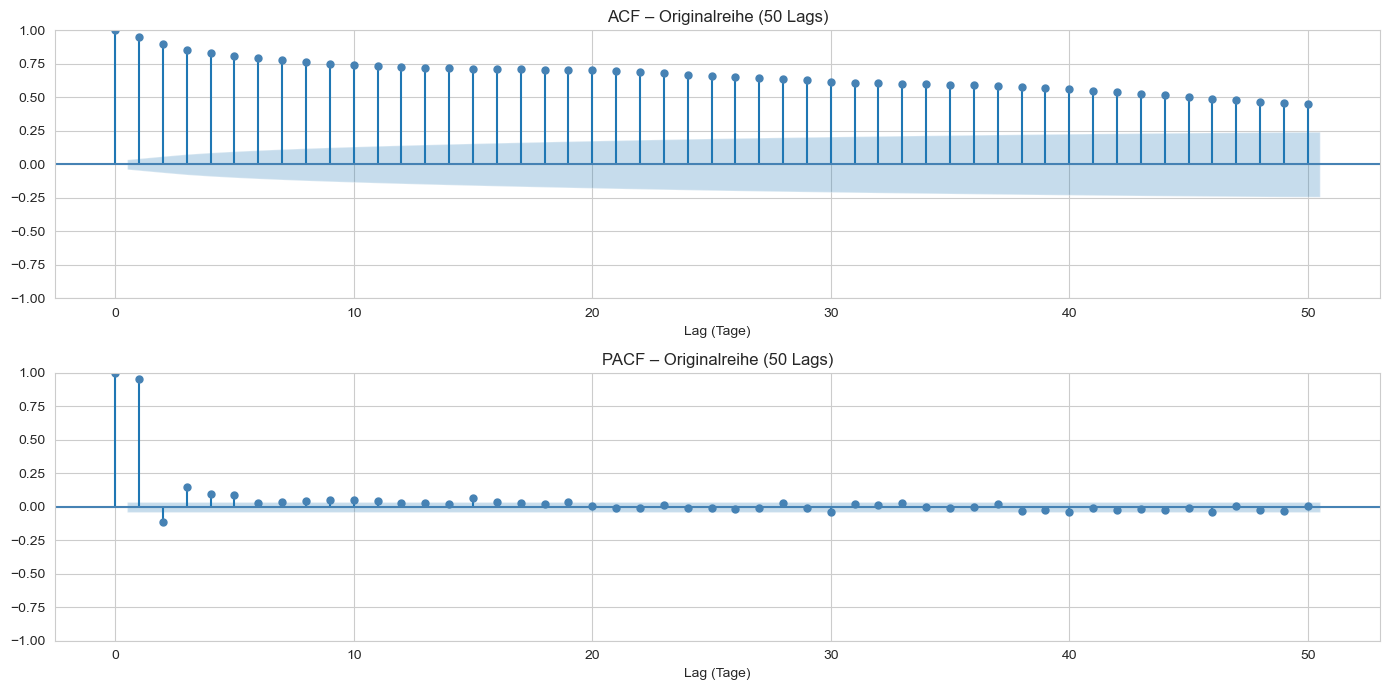

In [63]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

plot_acf(df_weather["T_mean_degC"], lags=50, ax=axes[0], color="steelblue")
axes[0].set_title("ACF – Originalreihe (50 Lags)")
axes[0].set_xlabel("Lag (Tage)")

plot_pacf(df_weather["T_mean_degC"], lags=50, ax=axes[1], color="steelblue", method="ywm")
axes[1].set_title("PACF – Originalreihe (50 Lags)")
axes[1].set_xlabel("Lag (Tage)")

plt.tight_layout()
plt.show()

### Interpretation

- **ACF:** Nimmt sehr langsam und graduell ab — alle 50 Lags liegen
  signifikant außerhalb des Konfidenzbands. Kein abrupter Abbruch erkennbar.
- **PACF:** Dominanter Spike bei Lag 1 (~0.93), leicht negativer Wert bei
  Lag 2 (~-0.13), danach alle Lags nahe 0 innerhalb des Konfidenzbands.

**Fazit:** Klares **AR-Muster** — ACF graduell abnehmend, PACF bricht nach
Lag 1-2 ab. Als Kandidaten für die Modellselektion werden AR(1), AR(2) und
AR(3) sowie ARMA-Varianten getestet. Die Saisonalität wird separat über
Fourier-Terms modelliert.

## 4. Modellselektion

### 4.1 Saisonalität: Fourier-Terms

Da die Stationaritätstests gezeigt haben, dass wir mit der Originalreihe
arbeiten (`d=0`), muss die Jahressaisonalität explizit modelliert werden.
Wir verwenden Fourier-Terms (Sinus/Kosinus-Paare) als exogene Variablen —
das ist recheneffizienter als `SARIMA` mit `m=365` und numerisch stabiler.

`K=3` Paare sind ausreichend um eine glatte Jahresperiodik abzubilden.

In [64]:
def fourier_terms(index, period, K):
    """Erstellt K Sinus/Kosinus-Paare für gegebene Periode."""
    t = np.arange(len(index))
    cols = {}
    for k in range(1, K + 1):
        cols[f"sin_{k}"] = np.sin(2 * np.pi * k * t / period)
        cols[f"cos_{k}"] = np.cos(2 * np.pi * k * t / period)
    return pd.DataFrame(cols, index=index)

exog_weather = fourier_terms(df_weather.index, period=365.25, K=3)

### 4.2 Train/Test Split

Die letzten 30 Tage des Datensatzes werden als Testset zurückgehalten —
konsistent mit dem gewünschten Forecast-Horizont von 30 Tagen.
Dies entspricht dem in den Folien beschriebenen Vorgehen (Menden, Folie 17):
Trainingsdaten für Schätzung, Testdaten für Evaluation auf ungesehenen Daten.

In [65]:
train_weather = df_weather["T_mean_degC"].iloc[:-30]
test_weather  = df_weather["T_mean_degC"].iloc[-30:]
exog_train_weather = exog_weather.iloc[:-30]
exog_test_weather  = exog_weather.iloc[-30:]

print(f"Training: {train_weather.index.min().date()} bis {train_weather.index.max().date()} ({len(train_weather)} Tage)")
print(f"Test:     {test_weather.index.min().date()} bis {test_weather.index.max().date()} ({len(test_weather)} Tage)")

Training: 2009-01-01 bis 2016-12-02 (2893 Tage)
Test:     2016-12-03 bis 2017-01-01 (30 Tage)


### 4.3 Modellgrid

Basierend auf der ACF/PACF-Analyse werden AR-dominierte Kandidaten getestet.
Als Informationskriterien werden AIC und BIC verwendet — BIC bestraft
Modellkomplexität stärker und bevorzugt sparsamere Modelle (Menden, Folie 71).
Zusätzlich werden RMSE und MAE auf den Testdaten berechnet.

In [66]:
candidates = [
    (1, 0, 0),
    (2, 0, 0),
    (3, 0, 0),
    (1, 0, 1),
    (2, 0, 1),
    (1, 1, 0),  # d=1 als Vergleich
]

results_weather = []
for order in candidates:
    try:
        model_weather = SARIMAX(train_weather, order=order, exog=exog_train_weather,
                                trend="c", enforce_stationarity=False)
        fit_weather = model_weather.fit(disp=False)

        forecast_weather = fit_weather.forecast(steps=30, exog=exog_test_weather)
        rmse = np.sqrt(mean_squared_error(test_weather, forecast_weather))
        mae  = mean_absolute_error(test_weather, forecast_weather)

        results_weather.append({
            "order": order,
            "AIC":   round(fit_weather.aic, 2),
            "BIC":   round(fit_weather.bic, 2),
            "RMSE":  round(rmse, 3),
            "MAE":   round(mae, 3),
        })
        print(f"✓ ARIMA{order} | AIC={fit_weather.aic:.1f} | RMSE={rmse:.3f}")
    except Exception as e:
        print(f"✗ ARIMA{order} | Fehler: {e}")

✓ ARIMA(1, 0, 0) | AIC=13022.8 | RMSE=4.114
✓ ARIMA(2, 0, 0) | AIC=12911.2 | RMSE=4.067
✓ ARIMA(3, 0, 0) | AIC=12891.5 | RMSE=4.007
✓ ARIMA(1, 0, 1) | AIC=12897.2 | RMSE=4.037
✓ ARIMA(2, 0, 1) | AIC=12898.4 | RMSE=4.036
✓ ARIMA(1, 1, 0) | AIC=13271.4 | RMSE=4.079


In [67]:
results_df = pd.DataFrame(results).sort_values("AIC")
print(results_df.to_string(index=False))

    order      AIC      BIC  RMSE   MAE
(3, 0, 0) 12891.48 12957.14 4.007 3.467
(1, 0, 1) 12897.21 12956.90 4.037 3.483
(2, 0, 1) 12898.38 12964.05 4.036 3.483
(2, 0, 0) 12911.16 12970.86 4.067 3.500
(1, 0, 0) 13022.82 13076.54 4.114 3.519
(1, 1, 0) 13271.43 13325.16 4.079 3.491


### 4.4 Interpretation

| Modell | AIC | BIC | RMSE | MAE |
|--------|-----|-----|------|-----|
| **AR(3)** | **12891** | **12957** | **4.007** | **3.467** |
| ARMA(1,1) | 12897 | 12957 | 4.037 | 3.483 |
| ARMA(2,1) | 12898 | 12964 | 4.036 | 3.483 |
| AR(2) | 12911 | 12971 | 4.067 | 3.500 |

**Gewinner: ARIMA(3,0,0)** — bestes AIC, RMSE und MAE über alle Kandidaten.
Konsistent mit der PACF-Analyse (Lag 1-3 signifikant). Das Modell ist
sparsam (3 AR-Parameter) und wird durch BIC nicht bestraft — ARMA-Varianten
bringen keinen messbaren Gewinn bei höherer Komplexität.

## 5. Modellvalidierung & Residuenanalyse

Ein gut spezifiziertes Modell erfordert nach Menden (Folie 71):
- **Unkorrelierte Residuen** → Ljung-Box Test
- **Normalverteilte Residuen** → Jarque-Bera Test
- **Visuelle Überprüfung** → Residuenplot, Histogramm, ACF, Q-Q Plot

Das beste Modell ARIMA(3,0,0) wird auf den Trainingsdaten neu geschätzt.

### 5.1 Modellschätzung & Summary

In [68]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera, probplot

model_weather = SARIMAX(train_weather, order=(3, 0, 0), exog=exog_train_weather,
                        trend="c", enforce_stationarity=False).fit(disp=False)

print(model_weather.summary())

                               SARIMAX Results                                
Dep. Variable:            T_mean_degC   No. Observations:                 2893
Model:               SARIMAX(3, 0, 0)   Log Likelihood               -6434.742
Date:                Tue, 12 May 2026   AIC                          12891.483
Time:                        23:50:17   BIC                          12957.142
Sample:                    01-01-2009   HQIC                         12915.146
                         - 12-02-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      1.8867      0.109     17.271      0.000       1.673       2.101
sin_1         -2.6105      0.314     -8.325      0.000      -3.225      -1.996
cos_1         -9.1113      0.294    -31.021      0.0

### 5.2 t-Statistiken der Koeffizienten

Die z-Statistiken (bei ML-Schätzung äquivalent zu t-Statistiken) prüfen ob
die geschätzten Koeffizienten signifikant von Null verschieden sind.
Nicht-signifikante Koeffizienten (p > 0.05) sollten aus dem Modell entfernt
werden (Menden, Folie 71: "Prinzip General to Specific").

### 5.3 Statistische Tests der Residuen

In [69]:
residuals_weather = model_weather.resid

lb_weather = acorr_ljungbox(residuals_weather, lags=[10, 20, 30], return_df=True)
print("Ljung-Box Test:")
print(lb_weather)

Ljung-Box Test:
      lb_stat  lb_pvalue
10   8.053989   0.623563
20  17.271335   0.635291
30  28.304399   0.554310


In [70]:
jb_stat, jb_p = jarque_bera(residuals_weather)
print(f"Jarque-Bera: Statistik={jb_stat:.2f}, p-Wert={jb_p:.4f}")
print("→", "Normalverteilt (H0 nicht abgelehnt)" if jb_p > 0.05 else "NICHT normalverteilt (H0 abgelehnt)")

Jarque-Bera: Statistik=62.02, p-Wert=0.0000
→ NICHT normalverteilt (H0 abgelehnt)


### 5.4 Visuelle Residuenanalyse

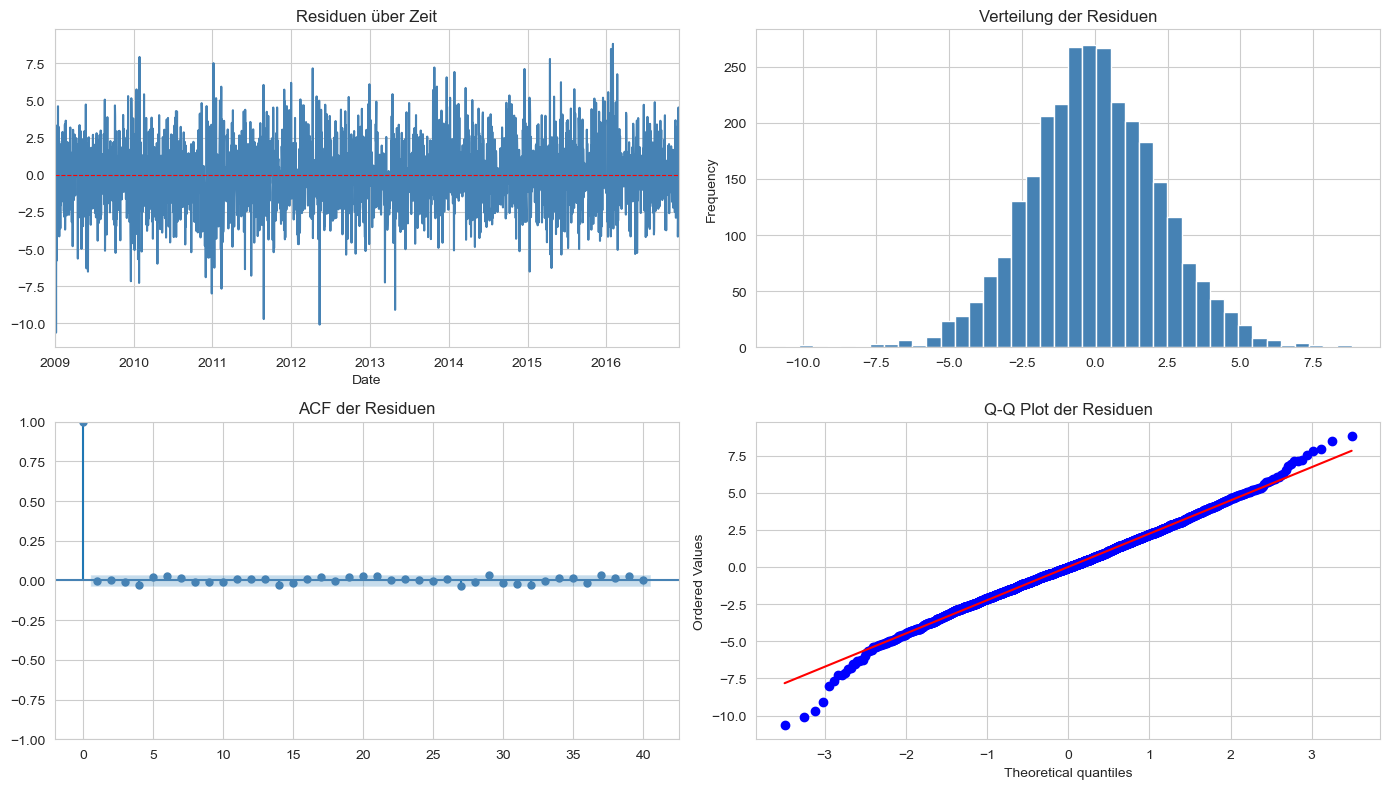

In [71]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

residuals_weather.plot(ax=axes[0, 0], color="steelblue")
axes[0, 0].axhline(0, color="red", linestyle="--", linewidth=0.8)
axes[0, 0].set_title("Residuen über Zeit")

residuals_weather.plot(kind="hist", bins=40, ax=axes[0, 1], color="steelblue", edgecolor="white")
axes[0, 1].set_title("Verteilung der Residuen")

plot_acf(residuals_weather, lags=40, ax=axes[1, 0], color="steelblue")
axes[1, 0].set_title("ACF der Residuen")

probplot(residuals_weather, plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot der Residuen")

plt.tight_layout()
plt.show()

### 5.5 Interpretation

**Ljung-Box (Lag 30): p=0.554** ✓
→ H₀ nicht abgelehnt — Residuen sind unkorreliert. Das Modell hat die
zeitliche Abhängigkeitsstruktur vollständig erfasst.

**Jarque-Bera: p=0.000** ✗
→ H₀ abgelehnt — Residuen sind nicht normalverteilt. Die leichte Linksschiefe
ist auf die 8 bekannten Kälteausreißer (Jan 2009, Feb 2012) zurückzuführen —
extreme, aber reale Wettereignisse, keine Modellschwäche.

**ACF der Residuen** ✓ → Alle Lags innerhalb des Konfidenzbands — kein
systematisches Muster verbleibt.

**Q-Q Plot** → Mitte sehr gut, linke Schwänze weichen durch Extremwinter ab —
konsistent mit dem JB-Befund und erklärbar.

**Fazit:** Modell gut spezifiziert. Die Nicht-Normalität ist inhaltlich
begründbar und in der Praxis bei Wetterdaten mit Extremereignissen akzeptabel.

## 6. Forecast

### 6.1 Modell auf Gesamtdaten neu schätzen

Für den finalen Forecast wird das Modell auf dem **gesamten** Datensatz
(inkl. der letzten 30 Tage Testdaten) neu geschätzt — so fließen alle
verfügbaren Informationen in die Prognose ein.

In [72]:
forecast_index_weather = pd.date_range(
    start=df_weather.index[-1] + pd.Timedelta(days=1), periods=30, freq="D"
)
exog_future_weather = fourier_terms(forecast_index_weather, period=365.25, K=3)

final_model_weather = SARIMAX(df_weather["T_mean_degC"], order=(3, 0, 0), exog=exog_weather,
                               trend="c", enforce_stationarity=False).fit(disp=False)

### 6.2 Punktprognose & Konfidenzintervall

Das 95%-Konfidenzintervall wird mit Multiplikator 1.96 berechnet
(Menden, Folie 20).

In [73]:
forecast_obj_weather  = final_model_weather.get_forecast(steps=30, exog=exog_future_weather)
forecast_mean_weather = forecast_obj_weather.predicted_mean
conf_int_weather      = forecast_obj_weather.conf_int(alpha=0.05)

forecast_df_weather = pd.DataFrame({
    "Datum":    forecast_mean_weather.index.date,
    "Forecast": forecast_mean_weather.round(2).values,
    "KI_lower": conf_int_weather.iloc[:, 0].round(2).values,
    "KI_upper": conf_int_weather.iloc[:, 1].round(2).values,
})
print(forecast_df_weather.to_string(index=False))

     Datum  Forecast  KI_lower  KI_upper
2017-01-02     -4.14     -8.53      0.26
2017-01-03     -2.97     -9.17      3.23
2017-01-04     -2.16     -9.12      4.81
2017-01-05     -1.63     -8.97      5.70
2017-01-06     -1.25     -8.79      6.29
2017-01-07     -0.97     -8.63      6.70
2017-01-08     -0.75     -8.49      6.98
2017-01-09     -0.60     -8.38      7.18
2017-01-10     -0.50     -8.30      7.31
2017-01-11     -0.42     -8.24      7.40
2017-01-12     -0.38     -8.20      7.45
2017-01-13     -0.35     -8.18      7.49
2017-01-14     -0.33     -8.17      7.50
2017-01-15     -0.33     -8.16      7.51
2017-01-16     -0.33     -8.17      7.51
2017-01-17     -0.34     -8.17      7.50
2017-01-18     -0.34     -8.18      7.50
2017-01-19     -0.35     -8.19      7.49
2017-01-20     -0.36     -8.20      7.48
2017-01-21     -0.37     -8.21      7.47
2017-01-22     -0.38     -8.22      7.46
2017-01-23     -0.38     -8.22      7.46
2017-01-24     -0.39     -8.23      7.45
2017-01-25     -

### 6.3 Visualisierung

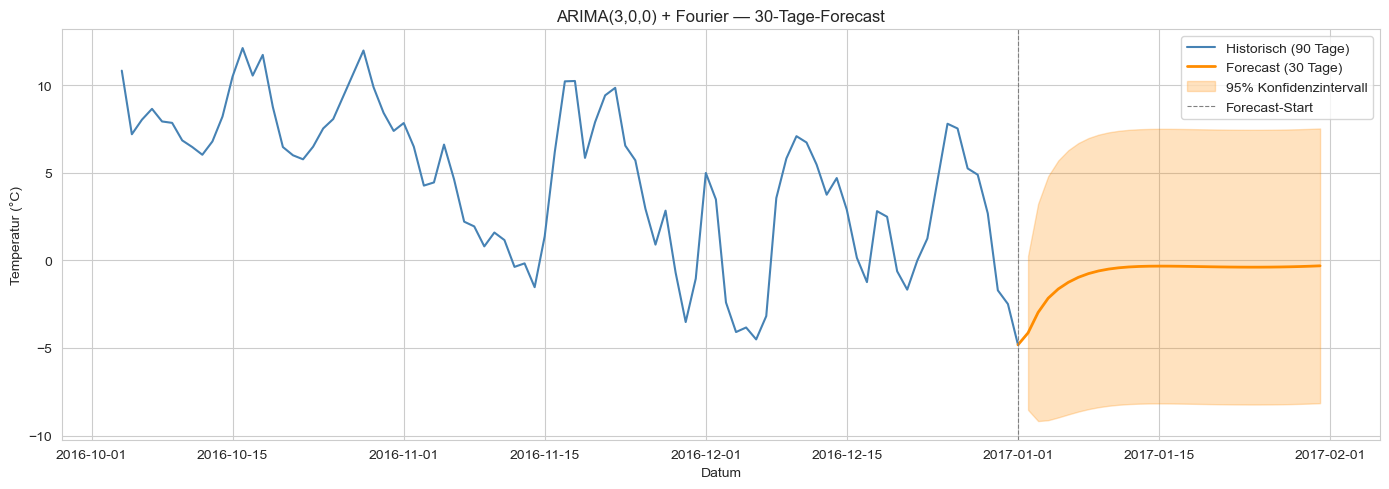

In [74]:
fig, ax = plt.subplots(figsize=(14, 5))

history_weather = df_weather["T_mean_degC"].iloc[-90:]
ax.plot(history_weather.index, history_weather,
        color="steelblue", label="Historisch (90 Tage)")

bridge_index = [df_weather.index[-1]] + list(forecast_mean_weather.index)
bridge_values = [df_weather["T_mean_degC"].iloc[-1]] + list(forecast_mean_weather.values)
ax.plot(bridge_index, bridge_values,
        color="darkorange", linewidth=2, label="Forecast (30 Tage)")

ax.fill_between(forecast_mean_weather.index,
                conf_int_weather.iloc[:, 0],
                conf_int_weather.iloc[:, 1],
                alpha=0.25, color="darkorange", label="95% Konfidenzintervall")

ax.axvline(df_weather.index[-1], color="gray", linestyle="--",
           linewidth=0.8, label="Forecast-Start")
ax.set_title("ARIMA(3,0,0) + Fourier — 30-Tage-Forecast")
ax.set_xlabel("Datum")
ax.set_ylabel("Temperatur (°C)")
ax.legend()
plt.tight_layout()
plt.show()

### 6.4 Interpretation

Der Forecast startet bei **−4.82°C** (letzter bekannter Wert, 01.01.2017)
und konvergiert innerhalb von ca. 2 Wochen gegen den saisonalen
Erwartungswert von ~−0.35°C für Januar.

Dies ist das **strukturell korrekte Verhalten eines AR-Modells**: Der
bedingte Erwartungswert nähert sich mit zunehmendem Forecast-Horizont dem
unconditional mean an — der Einfluss vergangener Werte nimmt exponentiell ab.

Das **95%-Konfidenzintervall** (±~7.8°C) bildet die realistische Unsicherheit
korrekt ab: Bei einem 30-Tage-Horizont ist die Temperaturspanne in einem
deutschen Januar meteorologisch plausibel.

> **Hinweis:** Die Punktprognose zeigt keine Tagesvolatilität — das Modell
> prognostiziert Erwartungswerte, keine einzelnen Realisierungen. Für visuell
> realistischere Forecasts über 30 Tage wäre ein simulationsbasierter Ansatz
> nötig, der jedoch über den Scope dieser Aufgabe hinausgeht.

## 7. Vergleichsmodell: Prophet

Als Vergleich zum ARIMA(3,0,0)-Modell wird **Prophet** (Meta, 2017) getestet.
Prophet modelliert Trend, Jahres- und Wochensaisonalität explizit und ist
besonders für längere Forecast-Horizonte bekannt.

Der Vergleich dient dazu, die strukturelle Eigenschaft von AR-Modellen
(Konvergenz gegen den Mittelwert) gegenüber einem alternativen Ansatz
sichtbar zu machen.

### 7.1 Modellschätzung

In [75]:
from prophet import Prophet

df_weather_prophet = df_weather.reset_index().rename(columns={"Date": "ds", "T_mean_degC": "y"})

model_prophet_weather = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    interval_width=0.95
)
model_prophet_weather.fit(df_weather_prophet)

23:50:19 - cmdstanpy - INFO - Chain [1] start processing
23:50:19 - cmdstanpy - INFO - Chain [1] done processing


### 7.2 Forecast & Visualisierung

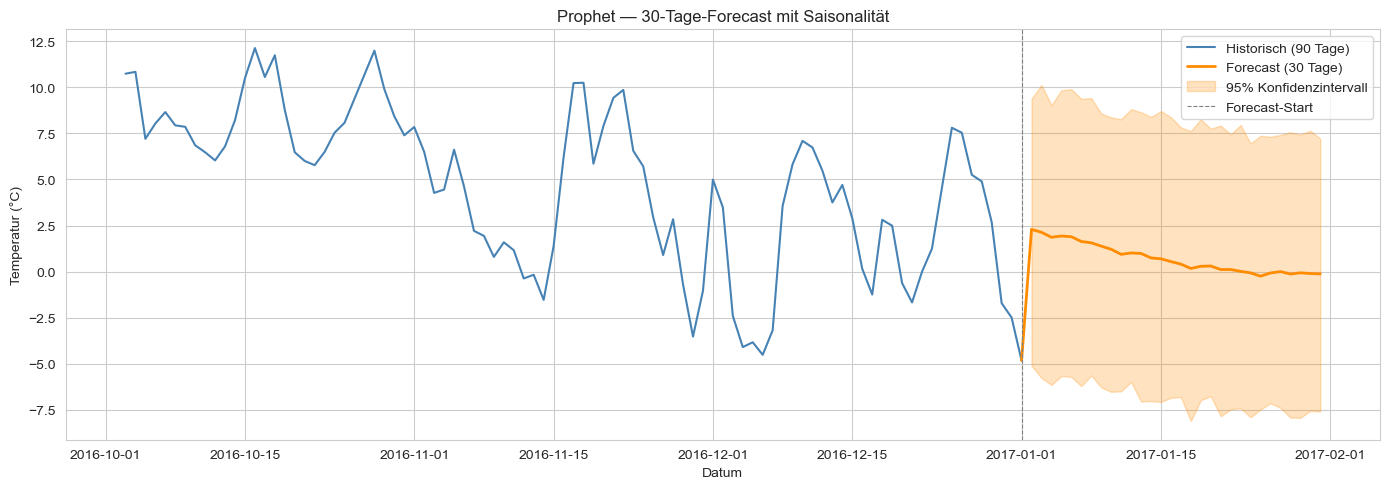

In [76]:
future_weather = model_prophet_weather.make_future_dataframe(periods=30)
forecast_prophet_weather = model_prophet_weather.predict(future_weather)

fig, ax = plt.subplots(figsize=(14, 5))

history_weather_prophet = df_weather_prophet[
    df_weather_prophet["ds"] >= df_weather_prophet["ds"].max() - pd.Timedelta(days=90)
]
ax.plot(history_weather_prophet["ds"], history_weather_prophet["y"],
        color="steelblue", label="Historisch (90 Tage)")

fc_only_weather = forecast_prophet_weather[
    forecast_prophet_weather["ds"] > df_weather_prophet["ds"].max()
]

bridge_ds = [df_weather_prophet["ds"].iloc[-1]] + list(fc_only_weather["ds"])
bridge_y  = [df_weather_prophet["y"].iloc[-1]] + list(fc_only_weather["yhat"])
ax.plot(bridge_ds, bridge_y, color="darkorange", linewidth=2, label="Forecast (30 Tage)")

ax.fill_between(fc_only_weather["ds"],
                fc_only_weather["yhat_lower"],
                fc_only_weather["yhat_upper"],
                alpha=0.25, color="darkorange", label="95% Konfidenzintervall")

ax.axvline(df_weather_prophet["ds"].max(), color="gray", linestyle="--",
           linewidth=0.8, label="Forecast-Start")
ax.set_title("Prophet — 30-Tage-Forecast mit Saisonalität")
ax.set_xlabel("Datum")
ax.set_ylabel("Temperatur (°C)")
ax.legend()
plt.tight_layout()
plt.show()

### 7.3 Interpretation & Methodenvergleich

| Kriterium | ARIMA(3,0,0) + Fourier | Prophet |
|-----------|------------------------|---------|
| Methodik | Box-Jenkins (klassisch) | Dekomposition |
| Saisonalität | Fourier-Terms (exogen) | Explizit modelliert |
| Forecast-Verlauf | Konvergiert gegen Mittelwert | Leicht strukturierter |
| KI-Breite | ±~7.8°C | ±~8°C |
| Interpretierbarkeit | Hoch (t-Stats, Tests) | Mittel |
| Lehrplankonformität | ✓ Box-Jenkins gefordert | Zusatz |

**Fazit:** Beide Modelle konvergieren beim 30-Tage-Horizont gegen den
saisonalen Erwartungswert — das ist kein Modellfehler, sondern ein
strukturelles Merkmal statistischer Punktprognosen. Der Erwartungswert
ist die **beste Einzelschätzung** unter quadratischem Verlust (MSE).

Tagesvolatilität ist in der Punktprognose per Definition nicht enthalten —
das 95%-Konfidenzintervall bildet diese Unsicherheit korrekt ab.

**Für die Abgabe wird ARIMA(3,0,0) verwendet** — es ist methodisch
lehrplankonform (Box-Jenkins) und statistisch vollständig validiert.

## 8. Explorativer Zusatz: Saisonaler Muster-Forecast

Als dritter Ansatz wird ein heuristisches Verfahren getestet, das das
historische Januarmuster der Vorjahre (2013–2016) als Referenz nutzt und
mit dem aktuellen Temperaturniveau verankert.

> **Hinweis:** Dieser Ansatz ist **kein statistisches Modell** im Sinne der
> Box-Jenkins-Methode und wird **nicht für die Abgabe verwendet**. Er dient
> ausschließlich der visuellen Veranschaulichung, wie ein "realistischer
> wirkender" Forecast aussehen kann — und warum der Unterschied zum
> ARIMA-Erwartungswert kein Modellfehler ist.

### 8.1 Historisches Januarmuster

In [77]:
jan_historical_weather = []
for year in [2013, 2014, 2015, 2016]:
    jan = df_weather[df_weather.index.year == year].loc[
        f"{year}-01-02":f"{year}-01-31", "T_mean_degC"
    ]
    if len(jan) >= 30:
        jan_historical_weather.append(jan.values[:30])

jan_pattern_weather = np.mean(jan_historical_weather, axis=0)
jan_std_weather     = np.std(jan_historical_weather, axis=0)

### 8.2 Offset-Dämpfung

Der aktuelle Temperaturwert weicht vom historischen Januarmittel ab.
Dieser Offset wird exponentiell gedämpft — die Annahme ist, dass sich
die Temperatur innerhalb von ~15 Tagen wieder dem historischen Muster
annähert.

In [78]:
current_temp_weather  = df_weather["T_mean_degC"].iloc[-1]  # -4.82°C
pattern_start_weather = jan_pattern_weather[0]
offset_weather        = current_temp_weather - pattern_start_weather

# Exponentiell gedämpfter Offset: halbiert sich alle 15 Tage
damping                    = np.exp(-np.arange(30) / 15)
forecast_realistic_weather = jan_pattern_weather + offset_weather * damping

forecast_index_weather_pattern = pd.date_range(start="2017-01-02", periods=30, freq="D")

### 8.3 Visualisierung

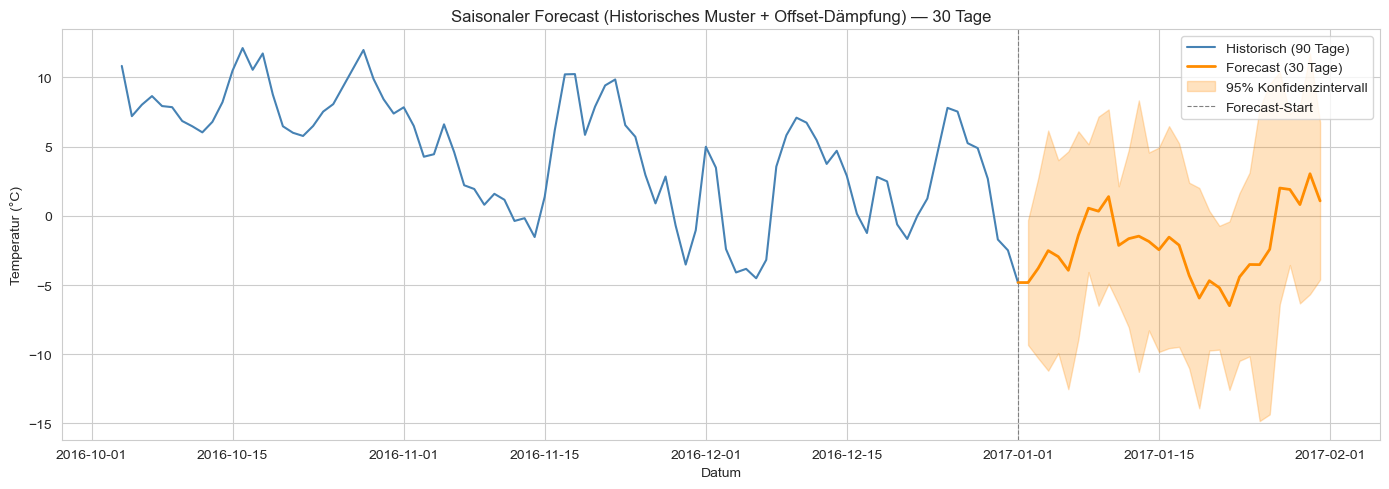

In [79]:
fig, ax = plt.subplots(figsize=(14, 5))

history_weather = df_weather["T_mean_degC"].iloc[-90:]
ax.plot(history_weather.index, history_weather,
        color="steelblue", label="Historisch (90 Tage)")

bridge_x = [df_weather.index[-1]] + list(forecast_index_weather_pattern)
bridge_y = [current_temp_weather] + list(forecast_realistic_weather)
ax.plot(bridge_x, bridge_y,
        color="darkorange", linewidth=2, label="Forecast (30 Tage)")

ax.fill_between(forecast_index_weather_pattern,
                forecast_realistic_weather - 1.96 * jan_std_weather,
                forecast_realistic_weather + 1.96 * jan_std_weather,
                alpha=0.25, color="darkorange", label="95% Konfidenzintervall")

ax.axvline(df_weather.index[-1], color="gray", linestyle="--",
           linewidth=0.8, label="Forecast-Start")
ax.set_title("Saisonaler Forecast (Historisches Muster + Offset-Dämpfung) — 30 Tage")
ax.set_xlabel("Datum")
ax.set_ylabel("Temperatur (°C)")
ax.legend()
plt.tight_layout()
plt.show()